# Agricultural Policy Insights

This project uses production, market price, and seed price data to generate useful insights for producers and competent institutions in agricultural policy. The focus is on clear, interpretable questions rather than broad exploratory analysis.

## Core Questions

1. Has the relationship between the seed price and the market price worsened over the years?
2. Does higher yield by region systematically push the selling price down in that year?
3. Can next-season sales price and margin be predicted from historical trends?
4. Which region offers the best sales-price-to-yield ratio for each crop, and where is it most profitable to plant?

## Presentation Goal

The notebook should support decision-making with a small number of focused, defensible findings that can be presented to stakeholders and aligned with the project guidelines.

In [1]:
import subprocess
import sys
from pathlib import Path
import pandas as pd

DATASET_PATH = Path("data/dataset.csv")
PIPELINE_SCRIPT = Path("scripts/run_pipeline.py")

if not DATASET_PATH.exists():
    print(f"{DATASET_PATH} not found -- running pipeline...")
    result = subprocess.run([sys.executable, str(PIPELINE_SCRIPT)])
    if result.returncode != 0:
        raise RuntimeError("Pipeline failed -- check output above.")
else:
    print(f"{DATASET_PATH} found -- loading directly.")

data\dataset.csv found -- loading directly.


In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,Year,Crop,Region,Area (ha),Total production (t),Yield (t/ha),Selling price (RSD/kg),Seed price (RSD/kg)
0,2010,Barley,Belgrade Region,7297.0,23371.0,3.2,15.95,NaN
1,2010,Corn,Belgrade Region,43090.0,259374.0,6.0,16.22,278.43
2,2010,Wheat,Belgrade Region,33256.0,111077.0,3.3,15.46,NaN
3,2010,Barley,Southern and Eastern Serbia Region,22141.0,53382.0,2.4,18.21,NaN
4,2010,Corn,Southern and Eastern Serbia Region,180470.0,952110.0,5.3,16.85,270.65


In [3]:
# Shared setup for the hypothesis cells
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

analysis_df = df.copy()
for column in ["Selling price (RSD/kg)", "Seed price (RSD/kg)", "Yield (t/ha)", "Area (ha)", "Total production (t)"]:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")

analysis_df["price_margin"] = analysis_df["Selling price (RSD/kg)"] - analysis_df["Seed price (RSD/kg)"]
analysis_df["margin_ratio"] = analysis_df["Selling price (RSD/kg)"] / analysis_df["Seed price (RSD/kg)"]

,Year,Crop,median_selling_price,median_seed_price,median_price_margin,median_margin_ratio
0,2010,Corn,16.420,271.965,-255.230,0.059536
1,2011,Barley,24.050,35.800,-10.520,0.683987
2,2011,Corn,22.510,296.010,-275.390,0.075888
3,2011,Wheat,25.100,36.610,-11.680,0.680835
4,2012,Barley,26.675,37.500,-10.950,0.709482
5,2012,Corn,26.755,299.885,-272.260,0.091077
6,2012,Wheat,26.740,41.500,-14.235,0.659976
7,2013,Barley,26.570,52.425,-25.755,0.510293
8,2013,Corn,26.115,388.230,-361.210,0.069992
9,2013,Wheat,25.850,54.745,-28.225,0.467040


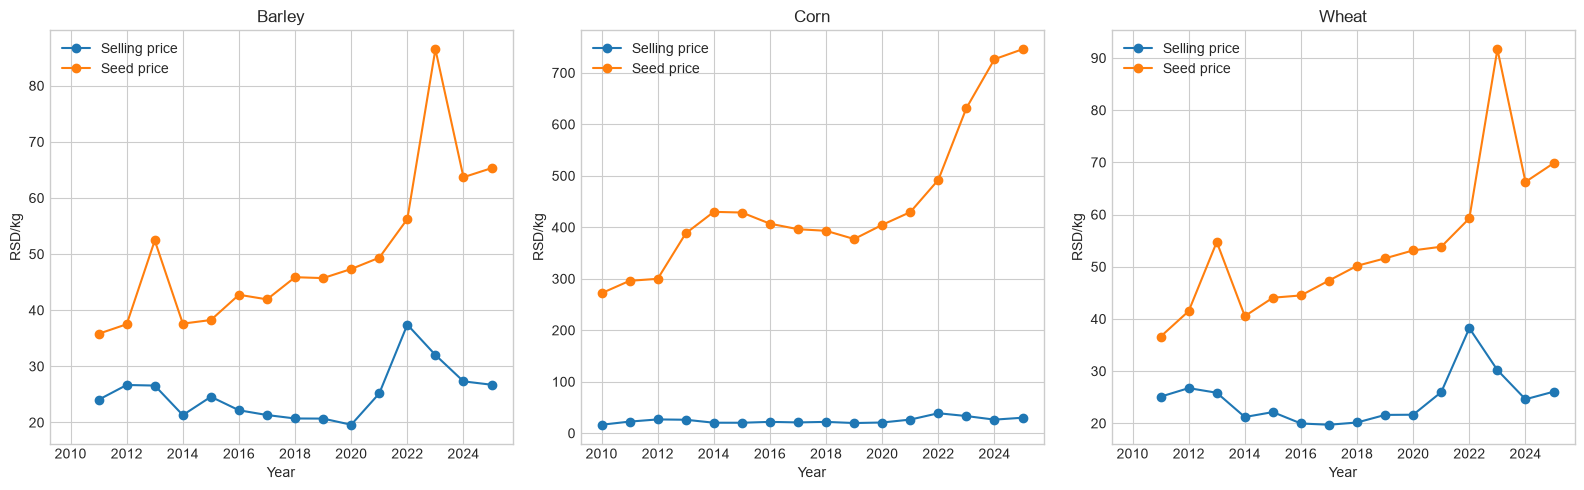

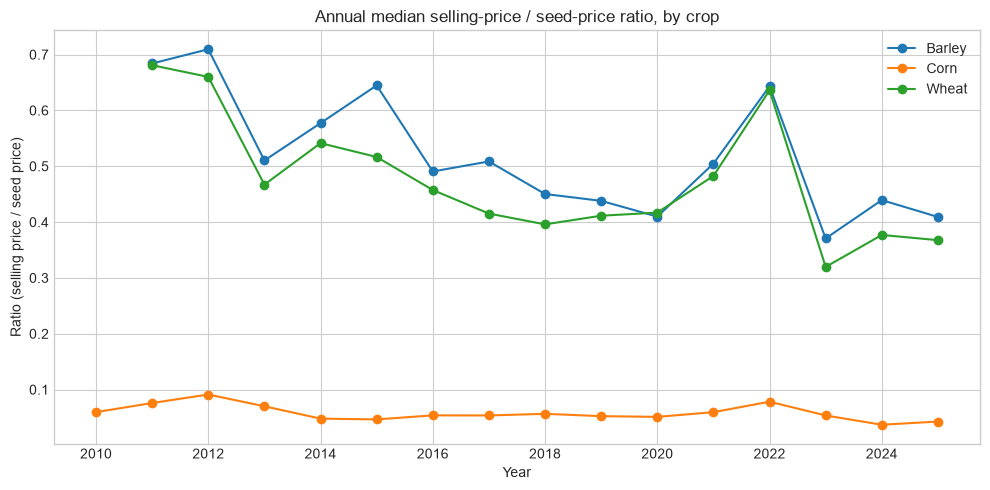

In [4]:
# Hypothesis 1: did the selling-price to seed-price relationship weaken over time?
annual_margin = (
    analysis_df.dropna(subset=["Selling price (RSD/kg)", "Seed price (RSD/kg)"])
    .groupby(["Year", "Crop"])
    .agg(
        median_selling_price=("Selling price (RSD/kg)", "median"),
        median_seed_price=("Seed price (RSD/kg)", "median"),
        median_price_margin=("price_margin", "median"),
        median_margin_ratio=("margin_ratio", "median"),
    )
    .reset_index()
)
display(annual_margin)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, crop in zip(axes, sorted(annual_margin["Crop"].unique())):
    subset = annual_margin[annual_margin["Crop"] == crop]
    ax.plot(subset["Year"], subset["median_selling_price"], marker="o", label="Selling price")
    ax.plot(subset["Year"], subset["median_seed_price"], marker="o", label="Seed price")
    ax.set_title(crop)
    ax.set_xlabel("Year")
    ax.set_ylabel("RSD/kg")
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for crop, subset in annual_margin.groupby("Crop"):
    ax.plot(subset["Year"], subset["median_margin_ratio"], marker="o", label=crop)
ax.set_title("Annual median selling-price / seed-price ratio, by crop")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio (selling price / seed price)")
ax.legend()
plt.tight_layout()
plt.show()

,Crop,n_observations,corr_yield_price
1,Corn,64.0,-0.409006
2,Wheat,64.0,0.244398
0,Barley,63.0,0.309271


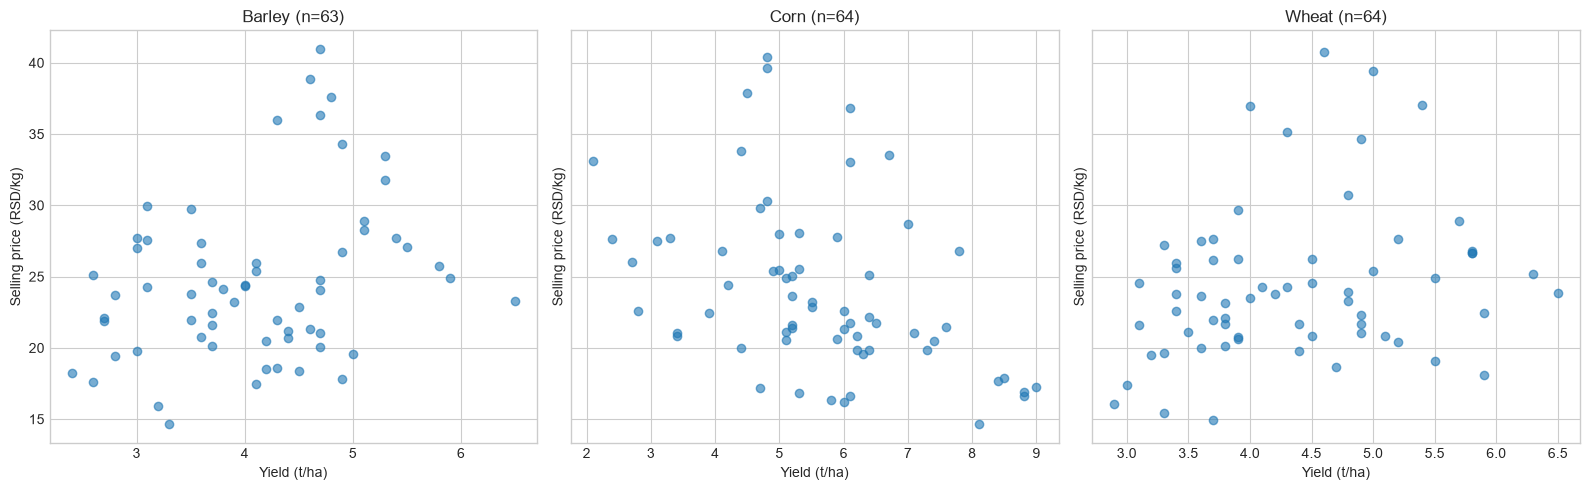

In [5]:
# Hypothesis 2: yield versus selling price, by crop
yield_price_pooled = (
    analysis_df.dropna(subset=["Yield (t/ha)", "Selling price (RSD/kg)"])
    .groupby("Crop")
    .apply(
        lambda frame: pd.Series(
            {
                "n_observations": len(frame),
                "corr_yield_price": frame["Yield (t/ha)"].corr(frame["Selling price (RSD/kg)"]),
            }
        )
    )
    .reset_index()
    .sort_values("corr_yield_price")
)
display(yield_price_pooled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, crop in zip(axes, sorted(analysis_df["Crop"].dropna().unique())):
    subset = analysis_df[analysis_df["Crop"] == crop].dropna(
        subset=["Yield (t/ha)", "Selling price (RSD/kg)"]
    )
    ax.scatter(subset["Yield (t/ha)"], subset["Selling price (RSD/kg)"], alpha=0.6)
    ax.set_title(f"{crop} (n={len(subset)})")
    ax.set_xlabel("Yield (t/ha)")
    ax.set_ylabel("Selling price (RSD/kg)")
plt.tight_layout()
plt.show()

,Crop,Region,forecast_year,predicted_selling_price,predicted_margin_ratio,history_years
0,Barley,Belgrade Region,2026,45.662,0.561357,5
1,Barley,Southern and Eastern Serbia Region,2026,24.865,0.313519,5
2,Barley,Sumadija and Western Serbia Region,2026,31.967,0.387281,5
3,Barley,Vojvodina Region,2026,25.693,0.343119,5
4,Corn,Belgrade Region,2026,30.068,0.035761,5
5,Corn,Southern and Eastern Serbia Region,2026,33.147,0.031079,5
6,Corn,Sumadija and Western Serbia Region,2026,28.299,0.029640,5
7,Corn,Vojvodina Region,2026,23.210,0.017037,5
8,Wheat,Belgrade Region,2026,25.301,0.311521,5
9,Wheat,Southern and Eastern Serbia Region,2026,25.122,0.300739,5


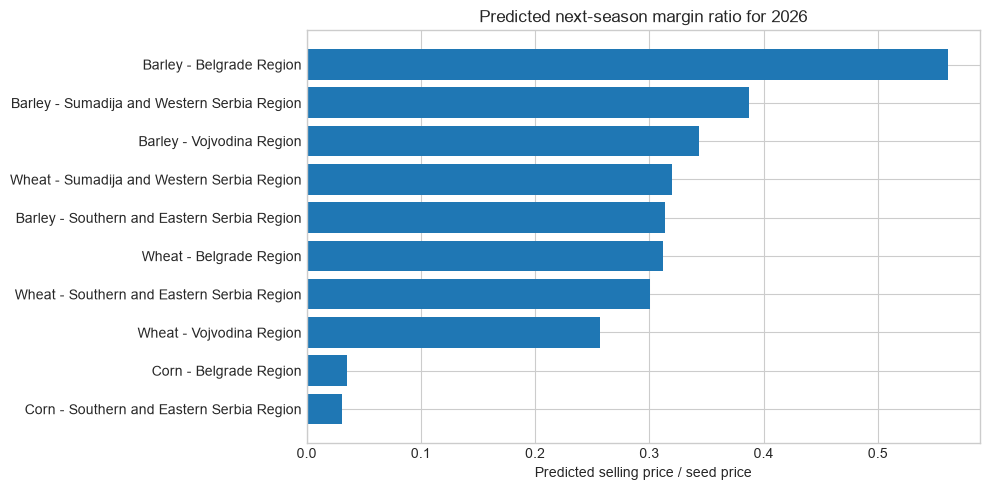

In [6]:
# Hypothesis 3: forecast next-season selling price and margin from trend
forecast_year = int(analysis_df["Year"].max()) + 1
forecast_rows = []

for (crop, region), group in analysis_df.dropna(subset=["Selling price (RSD/kg)", "margin_ratio"]).groupby(["Crop", "Region"]):
    history = group.sort_values("Year").tail(5)
    if len(history) < 3:
        continue

    years = history["Year"].to_numpy(dtype=float)
    price_values = history["Selling price (RSD/kg)"].to_numpy(dtype=float)
    margin_values = history["margin_ratio"].to_numpy(dtype=float)

    price_slope, price_intercept = np.polyfit(years, price_values, 1)
    margin_slope, margin_intercept = np.polyfit(years, margin_values, 1)

    forecast_rows.append(
        {
            "Crop": crop,
            "Region": region,
            "forecast_year": forecast_year,
            "predicted_selling_price": price_slope * forecast_year + price_intercept,
            "predicted_margin_ratio": margin_slope * forecast_year + margin_intercept,
            "history_years": len(history),
        }
    )

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.sort_values(["Crop", "Region"]).head(12))

fig, ax = plt.subplots(figsize=(10, 5))
if not forecast_df.empty:
    plot_forecast = forecast_df.sort_values("predicted_margin_ratio", ascending=False).head(10)
    ax.barh(plot_forecast["Crop"].astype(str) + " - " + plot_forecast["Region"].astype(str), plot_forecast["predicted_margin_ratio"])
    ax.set_title(f"Predicted next-season margin ratio for {forecast_year}")
    ax.set_xlabel("Predicted selling price / seed price")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

,Crop,Region,mean_selling_price,mean_yield,observation_count,gross_revenue_per_ha
2,Barley,Sumadija and Western Serbia Region,27.756875,3.98125,16,110507.058594
0,Corn,Vojvodina Region,21.150625,6.89375,16,145807.121094
1,Wheat,Vojvodina Region,23.166250,5.23125,16,121188.445313


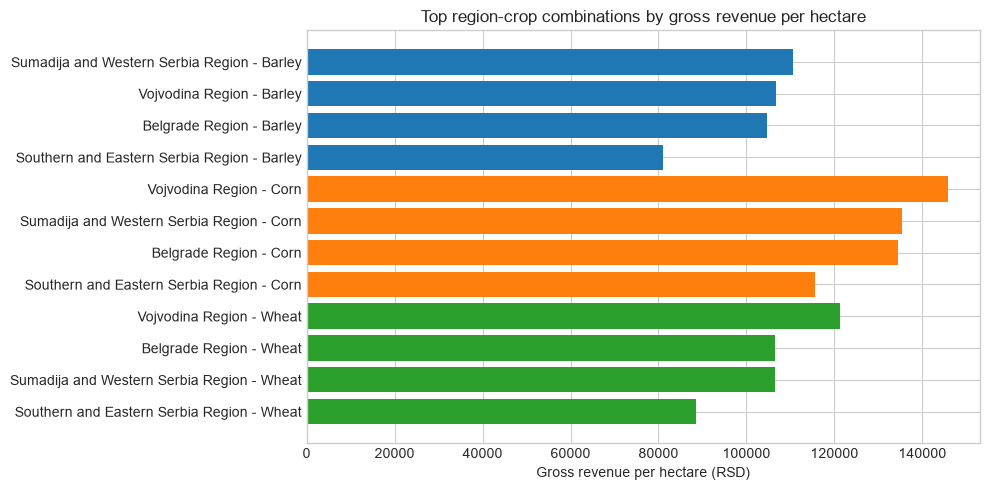

In [7]:
# Hypothesis 4: region-crop gross revenue ranking
region_crop_summary = (
    analysis_df.dropna(subset=["Selling price (RSD/kg)", "Yield (t/ha)"])
    .groupby(["Crop", "Region"])
    .agg(
        mean_selling_price=("Selling price (RSD/kg)", "mean"),
        mean_yield=("Yield (t/ha)", "mean"),
        observation_count=("Year", "count"),
    )
    .reset_index()
)
region_crop_summary["gross_revenue_per_ha"] = (
    region_crop_summary["mean_selling_price"] * region_crop_summary["mean_yield"] * 1000
)
best_region_by_crop = (
    region_crop_summary.sort_values("gross_revenue_per_ha", ascending=False)
    .groupby("Crop", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
display(best_region_by_crop.sort_values("Crop"))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = region_crop_summary.sort_values(["Crop", "gross_revenue_per_ha"], ascending=[True, False]).head(12)
for crop, subset in plot_data.groupby("Crop"):
    ax.barh(subset["Region"] + " - " + crop, subset["gross_revenue_per_ha"], label=crop)
ax.set_title("Top region-crop combinations by gross revenue per hectare")
ax.set_xlabel("Gross revenue per hectare (RSD)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation of the Four Hypotheses

1. **Selling price vs. seed price relationship**\
   All three crops show the same overall direction, the selling-price-to-seed-price
   ratio declined over time, especially after the mid-2010s. That means producers faced a less favorable price relationship in many later years, even though the trend was not perfectly monotonic.
   All three crops also show a shared spike in 2022, likely reflecting the global
   commodity price shock that year, before resuming the downward trend. Corn's seed
   price nearly tripled over the period, a much sharper increase
   than wheat or barley approximatly doubled, which is likely the main driver behind corn's ratio
   reaching its lowest point in 2024-2025. Because corn seed and grain prices operate
   on a very different absolute scale than wheat/barley, each crop is analyzed separately rather than blended into one figure.

2. **Yield vs. selling price**\
   Correlations are computed by pooling all year-region observations per crop
   (n=63-64), rather than one correlation per year (which would rely on only 4
   regional points and be unreliable). The relationship differs by crop, corn shows
   a moderate negative correlation, while wheat and barley show a mild positive correlation, 
   possibly reflecting that regions with better growing conditions achieve both higher yield
   and higher quality/price for these two crops.

3. **Next-season forecast**\
   A simple historical trend on the last 5 years of data predicts 2026 selling prices and
   margin ratios per crop-region. Corn's predicted margin ratio stays low across all
   regions, consistent with the declining trend in point 1. Wheat and
   barley predictions are more varied by region, but one result stands out: 
   Belgrade Region's barley forecast is far above every other region-crop combination. 
   Belgrade Region has the smallest barley-growing area of
   the four regions, so its 5-year history is thinner and noisier, and a short linear
   trend can extrapolate a recent local swing into an unrealistic forecast. This
   result should be treated as a caution about the forecast's reliability in
   low-volume regions, not as a genuine prediction.

4. **Region-crop gross revenue ranking**\
   Based on gross revenue per hectare, the strongest
   combinations are: corn in Vojvodina, wheat in Vojvodina, 
   and barley in Sumadija and Western Serbia.
   This is a gross figure, not net profit, since seed cost per hectare would require
   seeding-rate data not available in this dataset - but it is a reasonable
   first-pass indicator of which region-crop pairing generates the most revenue per
   unit of land.

## Policy takeaway

Producer margins have narrowed for all three crops since the early 2010s, most
sharply for corn, whose seed cost has grown much faster than its market price. The
2022 price shock offered temporary relief across all crops before the downward trend
resumed. Yield and price move together differently by crop (negative for corn,
positive for wheat and barley), and the most revenue-efficient region is
crop-specific (Vojvodina for corn and wheat, Sumadija and Western Serbia for
barley). Forecasts should be read as directional trends rather than precise
predictions, particularly in smaller-production regions where recent history is
thin and volatile.